In [1]:

import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))

import datetime
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import skew, norm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

from zhiyi.analysis.SE_analysis import get_site_index




In [2]:

SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne60/grids/UK_ne60_np4_SCRIP.nc"

filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist/'
                 'MUSICA_production3.2_BB.cam.h3.YYYY-MM-DD-00000.nc')
filebase_ne60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICAv0_ne60_production_annual/MUSICAv0_ne60_production_revision/atm/hist/'
                 'MUSICAv0_ne60_production_revision.cam.h3.YYYY-MM-DD-00000.nc')

start_date = datetime.date(2017, 12, 2)
end_date = datetime.date(2018, 12, 1)

city_lonlat = {
    'London': [360 - 0.213492, 51.521050],
    'Manchester': [360 - 2.237881, 53.481520],
    'Glasgow': [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
}


In [3]:

def collect_files(template, start, end):
    files = []
    by_day = "DD" in template

    cur = start
    while cur <= end:
        f = (template
             .replace("YYYY", cur.strftime("%Y"))
             .replace("MM", cur.strftime("%m"))
             .replace("DD", cur.strftime("%d")))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")

        if by_day:
            cur += datetime.timedelta(days=1)
        elif cur.month == 12:
            cur = datetime.date(cur.year + 1, 1, 1)
        else:
            cur = datetime.date(cur.year, cur.month + 1, 1)

    if not files:
        raise FileNotFoundError(
            f"No files found for template '{template}' between {start} and {end}."
        )
    return files

se_files_30 = collect_files(filebase_ne30, start_date, end_date)
se_files_60 = collect_files(filebase_ne60, start_date, end_date)

ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")
ds_ne60 = xr.open_mfdataset(se_files_60, combine="by_coords")

print("Datasets loaded!")


Datasets loaded!


In [4]:

Index_lonlat_30 = {}
Index_lonlat_60 = {}

for city, (lon360_c, lat_c) in city_lonlat.items():
    Index_lonlat_30[city] = get_site_index(lon360_c, lat_c, scrip_file=SCRIP_file)
    Index_lonlat_60[city] = get_site_index(lon360_c, lat_c, scrip_file=SCRIP_file_ne60)

TS = {}
TS_f09 = {}
for city in city_lonlat:
    idx30 = Index_lonlat_30[city]
    idx60 = Index_lonlat_60[city]
    TS[city] = ds_ne30['PM25'].values[:, -1, idx30] * 1e9
    TS_f09[city] = ds_ne60['PM25'].values[:, -1, idx60] * 1e9


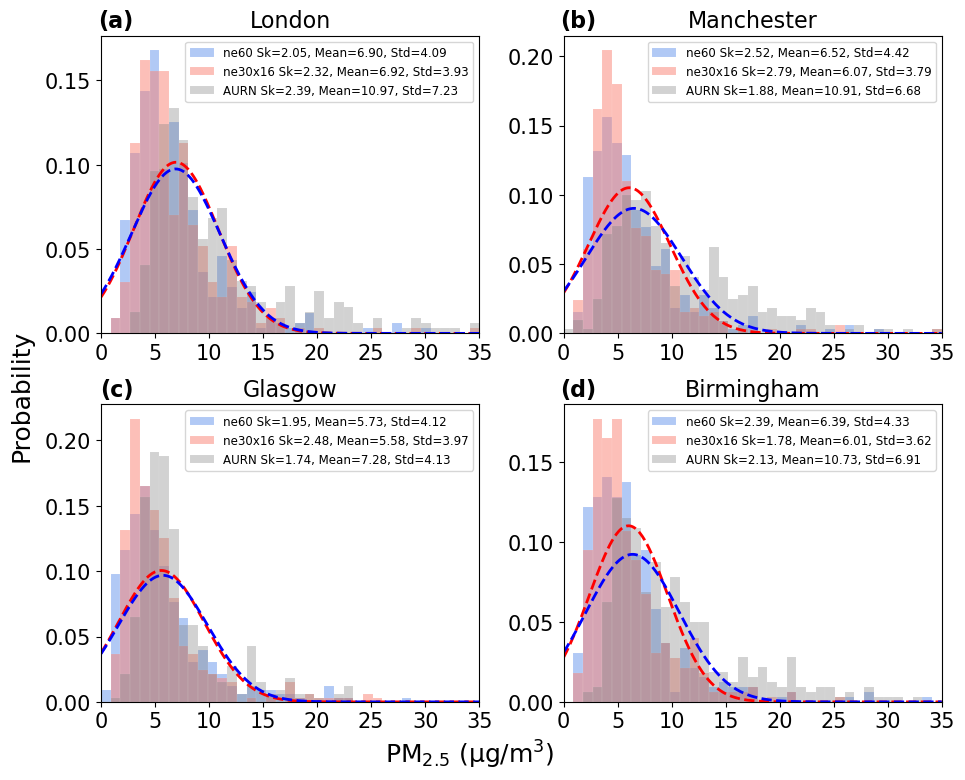

In [5]:

ycol = 'average'
obs_start_date = pd.to_datetime('2017-12-01')
obs_end_date = pd.to_datetime('2018-11-30')
obs_dir = '/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25'
obs_files = {
    'London': 'london_pm2.5.csv',
    'Manchester': 'manchester_pm2.5.csv',
    'Glasgow': 'glasgow_pm2.5.csv',
    'Birmingham': 'birmingham_pm2.5.csv',
}

def make_daily_stats(csv_path, ycol='average', start_date=None, end_date=None):
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(
        df['Date'].astype(str) + ' ' + df['Time'].astype(str),
        errors='coerce'
    )
    m = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    daily = (
        df.loc[m]
          .set_index('Date')
          .resample('D')[ycol]
          .agg(
              mean='mean',
              q25=lambda x: x.quantile(0.25),
              q75=lambda x: x.quantile(0.75)
          )
          .reset_index()
          .sort_values('Date')
    )
    return daily

obs_skew_map = {
    city: make_daily_stats(
        os.path.join(obs_dir, filename),
        ycol=ycol,
        start_date=obs_start_date,
        end_date=obs_end_date
    )
    for city, filename in obs_files.items()
}

cities = ['London', 'Manchester', 'Glasgow', 'Birmingham']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

xmin, xmax = 0, 35
bins = np.linspace(xmin, xmax, 40)

def clean_values(values):
    arr = np.asarray(values, dtype=float).ravel()
    return arr[np.isfinite(arr)]

def plot_norm_pdf(ax, x, values, color):
    mean_val = np.mean(values)
    std_val = np.std(values)
    if np.isfinite(std_val) and std_val > 0:
        ax.plot(x, norm.pdf(x, mean_val, std_val), linestyle='--', color=color, linewidth=2)

for i, city in enumerate(cities):
    ax = axes[i]

    obs_vals = clean_values(pd.to_numeric(obs_skew_map[city]['mean'], errors='coerce'))
    mod30_vals = clean_values(np.asarray(TS[city]).squeeze())
    mod60_vals = clean_values(np.asarray(TS_f09[city]).squeeze())

    sk30 = skew(mod30_vals, nan_policy='omit')
    sk60 = skew(mod60_vals, nan_policy='omit')
    skobs = skew(obs_vals, nan_policy='omit')

    mean30, std30 = np.mean(mod30_vals), np.std(mod30_vals)
    mean60, std60 = np.mean(mod60_vals), np.std(mod60_vals)
    meanobs, stdobs = np.mean(obs_vals), np.std(obs_vals)

    ax.hist(
        mod60_vals, bins=bins, density=True, alpha=0.5,
        color='cornflowerblue', edgecolor='white', linewidth=0.1,
        label=f'ne60 Sk={sk60:.2f}, Mean={mean60:.2f}, Std={std60:.2f}'
    )
    ax.hist(
        mod30_vals, bins=bins, density=True, alpha=0.5,
        color='salmon', edgecolor='white', linewidth=0.1,
        label=f'ne30x16 Sk={sk30:.2f}, Mean={mean30:.2f}, Std={std30:.2f}'
    )
    ax.hist(
        obs_vals, bins=bins, density=True, alpha=0.35,
        color='grey', edgecolor='white', linewidth=0.1,
        label=f'AURN Sk={skobs:.2f}, Mean={meanobs:.2f}, Std={stdobs:.2f}'
    )

    x = np.linspace(xmin, xmax, 500)
    plot_norm_pdf(ax, x, mod30_vals, 'r')
    plot_norm_pdf(ax, x, mod60_vals, 'b')

    ax.set_xlim(xmin, xmax)
    ax.set_title(city, fontsize=16)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.grid(False)
    ax.tick_params(labelsize=15)
    ax.legend(fontsize=8.5)

fig.text(0.5, 0.04, 'PM$_{2.5}$ (µg/m$^3$)', ha='center', fontsize=18)
fig.text(0.04, 0.5, 'Probability', va='center', rotation='vertical', fontsize=18)

labels = ['(a)', '(b)', '(c)', '(d)']
for ax, label in zip(axes, labels):
    ax.text(
        0.086, 1.09,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top', ha='right'
    )

plt.tight_layout(rect=[0.06, 0.06, 1, 1])


In [6]:

figure_data_dir = '/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data'
os.makedirs(figure_data_dir, exist_ok=True)
figureS4_path = os.path.join(figure_data_dir, 'FigureS4.nc')

cities = ['London', 'Manchester', 'Glasgow', 'Birmingham']
sources = ['ne60', 'ne30x16', 'AURN']
model_sources = ['ne60', 'ne30x16']
xmin, xmax = 0, 35
bins = np.linspace(xmin, xmax, 40)
pdf_x = np.linspace(xmin, xmax, 500)

series = {}
max_sample = 0
for city in cities:
    series[(city, 'ne60')] = np.asarray(TS_f09[city]).squeeze()
    series[(city, 'ne30x16')] = np.asarray(TS[city]).squeeze()
    series[(city, 'AURN')] = pd.to_numeric(obs_skew_map[city]['mean'], errors='coerce').values
    for source in sources:
        values = np.asarray(series[(city, source)], dtype=float).ravel()
        values = values[np.isfinite(values)]
        series[(city, source)] = values
        max_sample = max(max_sample, values.size)

pm25 = np.full((len(cities), len(sources), max_sample), np.nan)
skewness = np.full((len(cities), len(sources)), np.nan)
mean = np.full((len(cities), len(sources)), np.nan)
std = np.full((len(cities), len(sources)), np.nan)
pdf = np.full((len(cities), len(model_sources), pdf_x.size), np.nan)

for i, city in enumerate(cities):
    for j, source in enumerate(sources):
        values = series[(city, source)]
        pm25[i, j, :values.size] = values
        skewness[i, j] = skew(values, nan_policy='omit')
        mean[i, j] = np.mean(values)
        std[i, j] = np.std(values)
    for j, source in enumerate(model_sources):
        values = series[(city, source)]
        if np.isfinite(std[i, sources.index(source)]) and std[i, sources.index(source)] > 0:
            pdf[i, j, :] = norm.pdf(pdf_x, mean[i, sources.index(source)], std[i, sources.index(source)])

FigureS4 = xr.Dataset(
    data_vars={
        'pm25': (('city', 'source', 'sample'), pm25),
        'skewness': (('city', 'source'), skewness),
        'mean': (('city', 'source'), mean),
        'std': (('city', 'source'), std),
        'pdf': (('city', 'model_source', 'pdf_x'), pdf),
    },
    coords={
        'city': cities,
        'source': sources,
        'model_source': model_sources,
        'sample': np.arange(max_sample),
        'bin_edge': bins,
        'pdf_x': pdf_x,
    }
)

FigureS4.to_netcdf(figureS4_path)


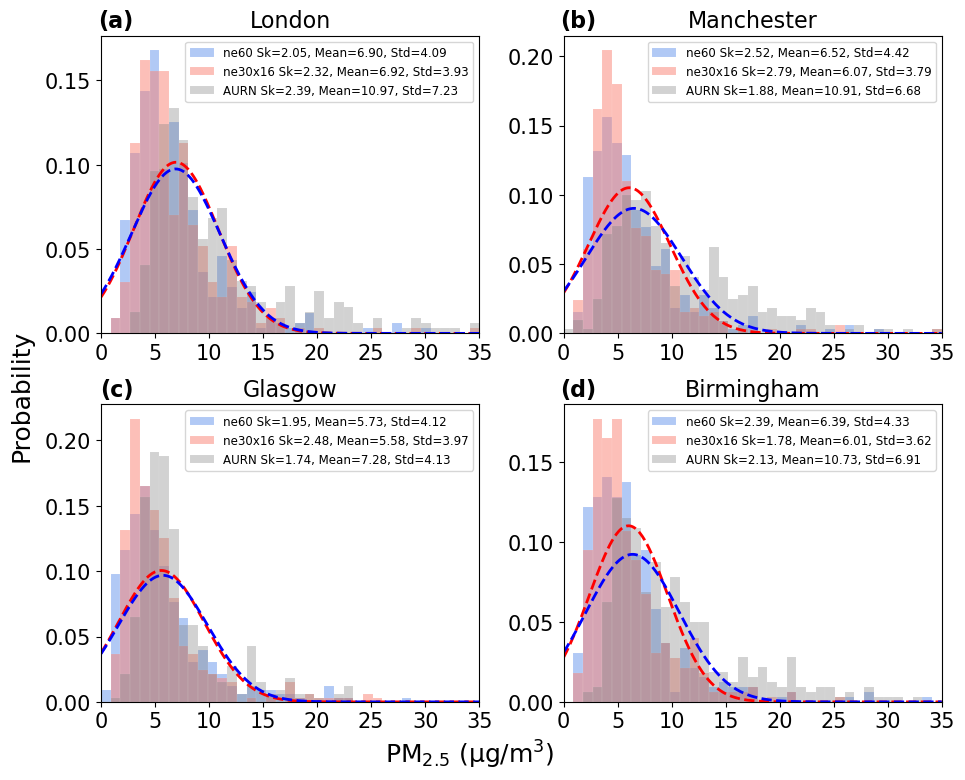

In [7]:

figureS4_path = '/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data/FigureS4.nc'
FigureS4 = xr.open_dataset(figureS4_path)

cities = ['London', 'Manchester', 'Glasgow', 'Birmingham']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

xmin, xmax = 0, 35
bins = FigureS4['bin_edge'].values

def clean_values(values):
    arr = np.asarray(values, dtype=float).ravel()
    return arr[np.isfinite(arr)]

def plot_norm_pdf(ax, x, values, color):
    mean_val = np.mean(values)
    std_val = np.std(values)
    if np.isfinite(std_val) and std_val > 0:
        ax.plot(x, norm.pdf(x, mean_val, std_val), linestyle='--', color=color, linewidth=2)

for i, city in enumerate(cities):
    ax = axes[i]

    obs_vals = clean_values(FigureS4['pm25'].sel(city=city, source='AURN').values)
    mod30_vals = clean_values(FigureS4['pm25'].sel(city=city, source='ne30x16').values)
    mod60_vals = clean_values(FigureS4['pm25'].sel(city=city, source='ne60').values)

    sk30 = skew(mod30_vals, nan_policy='omit')
    sk60 = skew(mod60_vals, nan_policy='omit')
    skobs = skew(obs_vals, nan_policy='omit')

    mean30, std30 = np.mean(mod30_vals), np.std(mod30_vals)
    mean60, std60 = np.mean(mod60_vals), np.std(mod60_vals)
    meanobs, stdobs = np.mean(obs_vals), np.std(obs_vals)

    ax.hist(
        mod60_vals, bins=bins, density=True, alpha=0.5,
        color='cornflowerblue', edgecolor='white', linewidth=0.1,
        label=f'ne60 Sk={sk60:.2f}, Mean={mean60:.2f}, Std={std60:.2f}'
    )
    ax.hist(
        mod30_vals, bins=bins, density=True, alpha=0.5,
        color='salmon', edgecolor='white', linewidth=0.1,
        label=f'ne30x16 Sk={sk30:.2f}, Mean={mean30:.2f}, Std={std30:.2f}'
    )
    ax.hist(
        obs_vals, bins=bins, density=True, alpha=0.35,
        color='grey', edgecolor='white', linewidth=0.1,
        label=f'AURN Sk={skobs:.2f}, Mean={meanobs:.2f}, Std={stdobs:.2f}'
    )

    x = np.linspace(xmin, xmax, 500)
    plot_norm_pdf(ax, x, mod30_vals, 'r')
    plot_norm_pdf(ax, x, mod60_vals, 'b')

    ax.set_xlim(xmin, xmax)
    ax.set_title(city, fontsize=16)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.grid(False)
    ax.tick_params(labelsize=15)
    ax.legend(fontsize=8.5)

fig.text(0.5, 0.04, 'PM$_{2.5}$ (µg/m$^3$)', ha='center', fontsize=18)
fig.text(0.04, 0.5, 'Probability', va='center', rotation='vertical', fontsize=18)

labels = ['(a)', '(b)', '(c)', '(d)']
for ax, label in zip(axes, labels):
    ax.text(
        0.086, 1.09,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top', ha='right'
    )

plt.tight_layout(rect=[0.06, 0.06, 1, 1])

from pathlib import Path

FIGURES_DIR = Path("/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures/SI")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RASTER_DPI = 300
png_path = FIGURES_DIR / "FigureS4.png"
pdf_path = FIGURES_DIR / "FigureS4.pdf"

fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches="tight", facecolor="white")

img = plt.imread(png_path)
height_px, width_px = img.shape[:2]
pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
pdf_ax.imshow(img)
pdf_ax.axis("off")
pdf_fig.savefig(pdf_path, format="pdf", dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor="white")
plt.close(pdf_fig)
FigureS4.close()
